<a href="https://colab.research.google.com/github/subhash0118/Machine-Learning-6-/blob/Anomaly-Detection-for-credit-cards/ML_CASE_STUDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (41242, 8)
   distance_from_home  distance_from_last_transaction  \
0           57.877857                        0.311140   
1           10.829943                        0.175592   
2            5.091079                        0.805153   
3            2.247564                        5.600044   
4           44.190936                        0.566486   

   ratio_to_median_purchase_price  repeat_retailer  used_chip  \
0                        1.945940              1.0        1.0   
1                        1.294219              1.0        0.0   
2                        0.427715              1.0        0.0   
3                        0.362663              1.0        1.0   
4                        2.222767              1.0        1.0   

   used_pin_number  online_order  fraud  
0              0.0           0.0      0  
1              0.0           0.0      0  
2              0.0           1.0      0  
3              0.0           1.0      0  
4              0.0           1

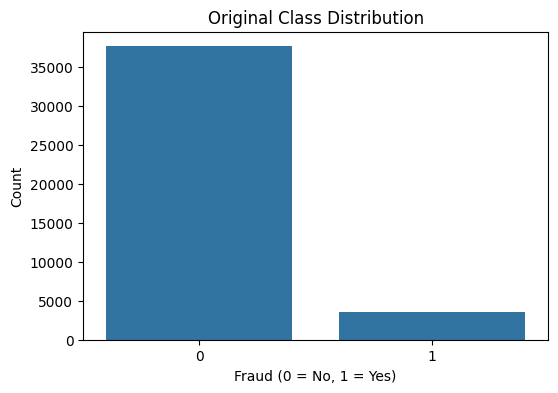

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 1: Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Load the CSV file (skip problematic rows)
df = pd.read_csv("/content/Card_Details.csv", on_bad_lines='skip')

# Step 3: Drop any rows with NaN values (especially in 'fraud' column)
df = df.dropna(subset=['fraud'])

# Step 4: Convert fraud to integer if needed
df['fraud'] = df['fraud'].astype(int)

# Step 5: Preview the data
print("Dataset Shape:", df.shape)
print(df.head())

# Step 6: Class Distribution
print("\nFraudulent vs Non-Fraudulent:")
print(df['fraud'].value_counts())

# Step 7: Preprocessing
X = df.drop('fraud', axis=1)
y = df['fraud']

# Drop NaNs in features (optional: you could fill them instead)
X = X.dropna()

# Align y with X after dropping rows
y = y[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Isolation Forest
iso_model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_preds = iso_model.fit_predict(X_scaled)
iso_preds = np.where(iso_preds == -1, 1, 0)  # -1 = anomaly

print("\n--- Isolation Forest Results ---")
print(confusion_matrix(y, iso_preds))
print(classification_report(y, iso_preds))

# Step 9: Local Outlier Factor
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_preds = lof_model.fit_predict(X_scaled)
lof_preds = np.where(lof_preds == -1, 1, 0)

print("\n--- Local Outlier Factor Results ---")
print(confusion_matrix(y, lof_preds))
print(classification_report(y, lof_preds))

# Step 10: Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=df)
plt.title("Original Class Distribution")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Step 11: Save Output (Optional)
df_result = df.copy()
df_result['Pred_IsoForest'] = iso_preds
df_result['Pred_LOF'] = lof_preds

df_result.to_csv("fraud_predictions_output.csv", index=False)

from google.colab import files
files.download("fraud_predictions_output.csv")
